In [1]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from google.colab import drive
from scipy.stats import friedmanchisquare, rankdata
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [3]:
# dataset path
dataset_path = "/content/drive/MyDrive/lecture_data/Supervised/Datasets_Assignment01"

In [4]:
# The four datasets available
dataset_files = sorted(
    [f for f in os.listdir(dataset_path) if f.startswith("dataset") and f.endswith(".mat")]
)
print("Datasets found:", dataset_files)

Datasets found: ['dataset1.mat', 'dataset2.mat', 'dataset3.mat', 'dataset4.mat']


In [5]:
#  preview of  dataset 1
datasetone = sio.loadmat(os.path.join(dataset_path, "dataset1.mat"))
X_preview = datasetone["data"]
y_preview = datasetone["labels"].ravel()

print("dataset1 data shape :", X_preview.shape)
print("dataset1 labels shape:", y_preview.shape)
print("Classes present     :", np.unique(y_preview))
print("First 3 labels      :", y_preview[:3])

dataset1 data shape : (300, 2)
dataset1 labels shape: (300,)
Classes present     : [1 2]
First 3 labels      : [1 1 1]


In [6]:
# Dataset overview table
overview_rows = []
for i in range(1,5):

    dataset = sio.loadmat(os.path.join(dataset_path, f"dataset{i}.mat"))
    X = dataset["data"]
    y = dataset["labels"].ravel()

    classes, counts = np.unique(y, return_counts=True)
    class_counts = dict(zip(classes, counts))

    overview_rows.append({
        "Dataset": f"dataset{i}",
        "Samples": X.shape[0],
        "Features": X.shape[1],
        "Class 1 count": class_counts.get(1,0),
        "Class 2 count": class_counts.get(2,0),
        "Class 2 ratio": np.mean(y == 2)
    })

overview_df = pd.DataFrame(overview_rows)
print(overview_df)

    Dataset  Samples  Features  Class 1 count  Class 2 count  Class 2 ratio
0  dataset1      300         2            100            200       0.666667
1  dataset2      300         2            100            200       0.666667
2  dataset3      600         2            200            400       0.666667
3  dataset4      600         2            300            300       0.500000


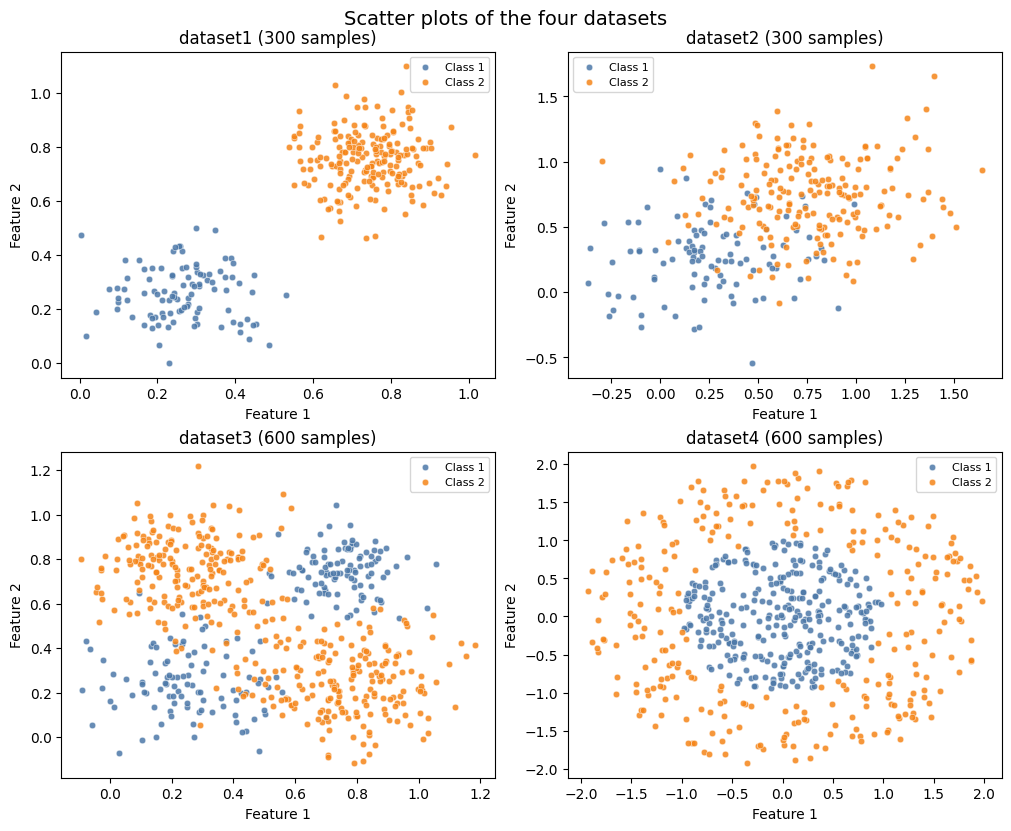

In [7]:
# Scatter plot of the four datasets
palette = {1: "#4C78A8", 2: "#F58518"}
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

for ax, i in zip(axes.flat, range(1,5)):
    dataset = sio.loadmat(os.path.join(dataset_path, f"dataset{i}.mat"))
    X = dataset["data"]
    y = dataset["labels"].ravel()

    for cls in np.unique(y):
        pts = X[y == cls]
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            s=22,
            alpha=0.85,
            color=palette.get(cls, "gray"),
            label=f"Class {cls}",
            edgecolor="white",
            linewidth=0.35
        )

    ax.set_title(f"dataset{i} ({X.shape[0]} samples)")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(frameon=True, fontsize=8)

fig.suptitle("Scatter plots of the four datasets", fontsize=14, y=1.02)
plt.show()

In [8]:
# initialize result containers
accuracy_5x2 = []

# Mean accuracy per dataset (mean over the 5 repetitions of 2-fold CV)
acc_svm_rbf = []
acc_tree = []
acc_knn = []

# Store all 5x2 scores for optional visualization/debugging
all_scores_svm_rbf = []
all_scores_tree = []
all_scores_knn = []

In [9]:
# define the three classifiers
# SVM and KNN are wrapped in a pipeline with StandardScaler.
# The Decision Tree does not require feature scaling.
svm_rbf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=1.0, gamma="scale")
)

tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=20,
    random_state=42
)

knn = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=3, metric="minkowski", p=2)
)

classifiers = {
    "RBF SVM": svm_rbf,
    "Decision Tree": tree,
    "KNN": knn
}

In [10]:
# 5-times 2-fold cross validation on each of the 4 datasets
# The split is stratified manually so that each class contributes half of its samples
# To the training split and the other half to the test split at each repetition.
rng = np.random.default_rng(42)

for ndataset in range(1, 5):
    dataset = sio.loadmat(os.path.join(dataset_path, f"dataset{ndataset}.mat"))
    data = dataset["data"]
    labels = dataset["labels"].ravel()

    accuracy_times_svm_rbf = []
    accuracy_times_tree = []
    accuracy_times_knn = []

    for ntimes in range(5):
        idx_tr = []
        idx_te = []

        # stratified 2-fold split
        for nclass in np.unique(labels):
            idx = np.where(labels == nclass)[0]
            idx = rng.permutation(idx)

            n_half = len(idx) // 2
            idx_tr.extend(idx[:n_half])
            idx_te.extend(idx[n_half:])

        idx_tr = np.array(idx_tr)
        idx_te = np.array(idx_te)

        labels_tr = labels[idx_tr]
        labels_te = labels[idx_te]
        data_tr = data[idx_tr, :]
        data_te = data[idx_te, :]

        split_results = {}

        # First fold: train on train split, test on test split
        # Second fold: swap train and test, then average the two accuracies
        for name, clf in classifiers.items():
            model_1 = clone(clf)
            model_1.fit(data_tr, labels_tr)
            pred1 = model_1.predict(data_te)
            accuracy1 = np.mean(pred1 == labels_te)

            model_2 = clone(clf)
            model_2.fit(data_te, labels_te)
            pred2 = model_2.predict(data_tr)
            accuracy2 = np.mean(pred2 == labels_tr)

            split_results[name] = (accuracy1 + accuracy2) / 2.0

        accuracy_times_svm_rbf.append(split_results["RBF SVM"])
        accuracy_times_tree.append(split_results["Decision Tree"])
        accuracy_times_knn.append(split_results["KNN"])

    # Mean over the 5 repetitions for the current dataset
    dataset_mean_svm = float(np.mean(accuracy_times_svm_rbf))
    dataset_mean_tree = float(np.mean(accuracy_times_tree))
    dataset_mean_knn = float(np.mean(accuracy_times_knn))

    acc_svm_rbf.append(dataset_mean_svm)
    acc_tree.append(dataset_mean_tree)
    acc_knn.append(dataset_mean_knn)

    # Keep the per-dataset SVM means in the original variable name as well
    accuracy_5x2.append(dataset_mean_svm)

    # Keep all repetition scores for later inspection/visualization
    all_scores_svm_rbf.extend(accuracy_times_svm_rbf)
    all_scores_tree.extend(accuracy_times_tree)
    all_scores_knn.extend(accuracy_times_knn)

print("Average 5x2 CV accuracies on the 4 datasets")
print("RBF SVM       :", acc_svm_rbf)
print("Decision Tree :", acc_tree)
print("KNN           :", acc_knn)

Average 5x2 CV accuracies on the 4 datasets
RBF SVM       : [1.0, 0.8806666666666667, 0.93, 0.976]
Decision Tree : [0.9946666666666667, 0.8026666666666665, 0.8963333333333333, 0.958]
KNN           : [1.0, 0.8533333333333333, 0.9129999999999999, 0.9710000000000001]


In [11]:
# Friedman test
# Each list contains one mean accuracy per dataset.
# The test checks whether the three classifiers differ significantly across datasets.
stat, p_value = friedmanchisquare(acc_svm_rbf, acc_tree, acc_knn)

print("Friedman test statistic =", stat)
print("p-value =", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject H0: there is a statistically significant difference among the classifiers.")
else:
    print("Fail to reject H0: no statistically significant difference among the classifiers.")

Friedman test statistic = 7.6
p-value = 0.022370771856165598
Reject H0: there is a statistically significant difference among the classifiers.


In [12]:
# results table for the four datasets
datasets = [f"dataset{i+1}" for i in range(len(acc_svm_rbf))]

df_results = pd.DataFrame({
    "Dataset": datasets,
    "RBF SVM": acc_svm_rbf,
    "Decision Tree": acc_tree,
    "KNN": acc_knn
})

df_results.loc["Mean"] = [
    "Mean",
    np.mean(acc_svm_rbf),
    np.mean(acc_tree),
    np.mean(acc_knn)
]

df_results = df_results.round(4)
print(df_results)

       Dataset  RBF SVM  Decision Tree     KNN
0     dataset1   1.0000         0.9947  1.0000
1     dataset2   0.8807         0.8027  0.8533
2     dataset3   0.9300         0.8963  0.9130
3     dataset4   0.9760         0.9580  0.9710
Mean      Mean   0.9467         0.9129  0.9343


In [13]:
# compute the mean accuracy across datasets and identify the best classifier
results = np.array([acc_svm_rbf, acc_tree, acc_knn]).T
classifier_names = ["RBF SVM", "Decision Tree", "KNN"]
mean_accuracies = np.mean(results, axis=0)

print("Mean accuracy across the 4 datasets:")
for name, acc in zip(classifier_names, mean_accuracies):
    print(f"{name}: {acc:.4f}")

best_idx = np.argmax(mean_accuracies)
print("\nBest average classifier:", classifier_names[best_idx])

Mean accuracy across the 4 datasets:
RBF SVM: 0.9467
Decision Tree: 0.9129
KNN: 0.9343

Best average classifier: RBF SVM


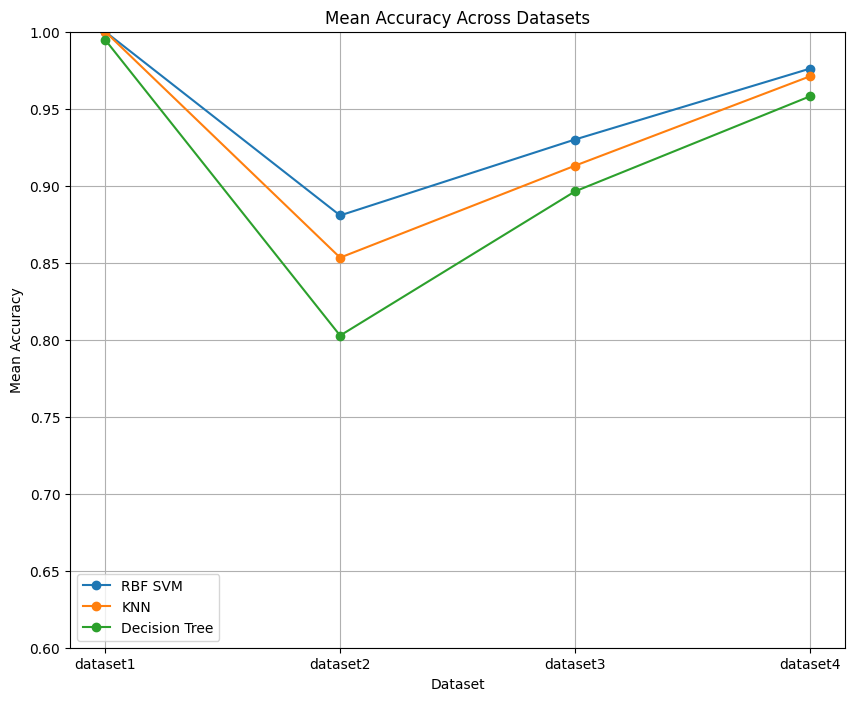

In [14]:
# plot of dataset vs mean accuracy for each classifier
plt.figure(figsize=(10,8))

# remove the "Mean" row
datasets = df_results.iloc[:-1]["Dataset"].tolist()

svm = df_results.iloc[:-1]["RBF SVM"].values
knn = df_results.iloc[:-1]["KNN"].values
decision_tree = df_results.iloc[:-1]["Decision Tree"].values

plt.plot(datasets, svm, marker='o', label='RBF SVM')
plt.plot(datasets, knn, marker='o', label='KNN')
plt.plot(datasets, decision_tree, marker='o', label='Decision Tree')

plt.title("Mean Accuracy Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("Mean Accuracy")
plt.legend()
plt.ylim(0.6, 1.0)

plt.grid(True)


plt.show()

In [15]:
# compute average classifier ranks across datasets
# Higher accuracy gets better (smaller) rank, so we rank the negative accuracies.
ranks = np.array([rankdata(-row) for row in results])
avg_ranks = np.mean(ranks, axis=0)

rank_df = pd.DataFrame({
    "Classifier": classifier_names,
    "Average Rank": avg_ranks
}).sort_values("Average Rank")

print(rank_df.round(4))

      Classifier  Average Rank
0        RBF SVM         1.125
2            KNN         1.875
1  Decision Tree         3.000


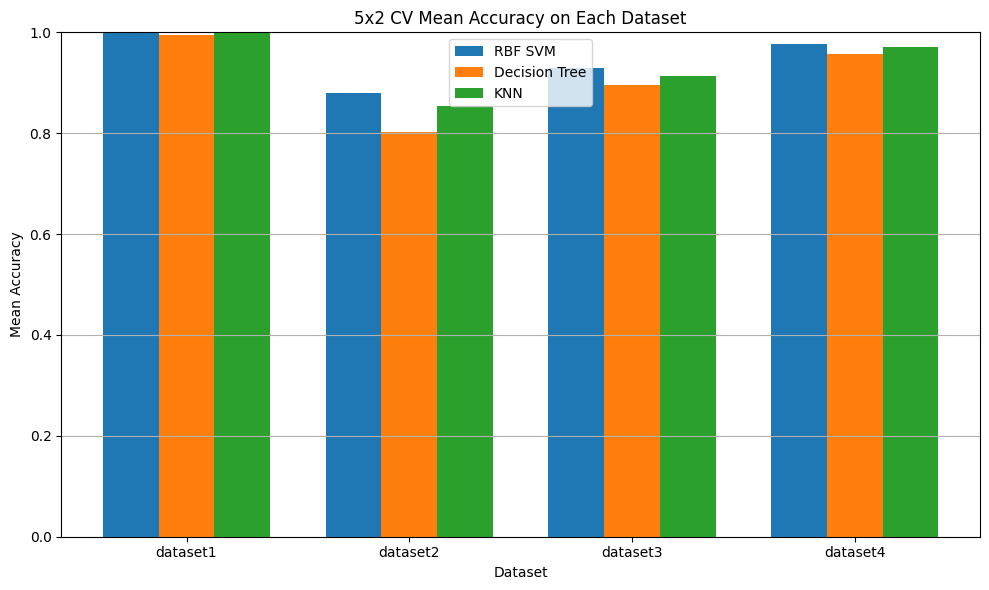

In [16]:
# Bar chart for the four datasets
datasets_plot = datasets
x = np.arange(len(datasets_plot))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, acc_svm_rbf, width, label="RBF SVM")
plt.bar(x, acc_tree,width, label="Decision Tree")
plt.bar(x + width, acc_knn, width, label="KNN")

plt.xticks(x, datasets_plot)
plt.ylabel("Mean Accuracy")
plt.xlabel("Dataset")
plt.title("5x2 CV Mean Accuracy on Each Dataset")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()